# 🏋️ RevFit Pose – EC3D Dataset Pipeline

This notebook processes the **EC3D (Exercise Correction in 3D)** dataset, which provides **pre-stored 3D skeleton landmarks** in pickle format — no MediaPipe extraction needed.

## Pipeline
1. **Mount Drive** and load the pickle file
2. **Explore** the dataset structure (labels, poses, exercise classes, subjects)
3. **Feature Engineering** – normalize, compute angles/velocities using the pre-stored 25-joint 3D landmarks
4. **Train / Test Split** – Subjects 1–3 for training, Subject 4 for testing (standard EC3D protocol)
5. **Model Training** – Classify exercise type + correctness
6. **Evaluation** – Accuracy, confusion matrix, classification report

---
## 1. Mount Google Drive & Import Dependencies

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

NumPy version: 2.0.2
Pandas version: 2.2.2


---
## 2. Configure Paths & Load Pickle Data

The EC3D dataset is stored as a **pickle** file (`data_3D.pickle`), NOT zipped.  
It contains:
- `labels`: metadata for each frame `[act, sub, lab, rep, frame]`
- `poses`: 3D coordinates with shape `(N_frames, 3, 25)` — xyz × 25 joints

In [3]:
# ============================================================
# PATHS – Update these to match your Google Drive layout
# ============================================================
DRIVE_ROOT = '/content/drive/MyDrive/'

DRIVE_DATASET_DIR = os.path.join(DRIVE_ROOT, 'EC3D_dataset')

PICKLE_PATH = os.path.join(DRIVE_DATASET_DIR, 'data_3D.pickle')

if not os.path.exists(PICKLE_PATH):
    # Try alternate name
    alt_path = os.path.join(DRIVE_DATASET_DIR, 'data.pickle')
    if os.path.exists(alt_path):
        PICKLE_PATH = alt_path
        print(f"Using alternate pickle: {PICKLE_PATH}")
    else:
        raise FileNotFoundError(
            f"Pickle file not found at {PICKLE_PATH}\n"
            f"Please ensure the EC3D dataset is in: {DRIVE_DATASET_DIR}"
        )

print(f"Dataset dir  : {DRIVE_DATASET_DIR}")
print(f"Pickle file  : {PICKLE_PATH}")
print(f"File size    : {os.path.getsize(PICKLE_PATH) / 1024 / 1024:.2f} MB")

Dataset dir  : /content/drive/MyDrive/EC3D_dataset
Pickle file  : /content/drive/MyDrive/EC3D_dataset/data_3D.pickle
File size    : 20.45 MB


In [4]:
# Load the pickle file
with open(PICKLE_PATH, 'rb') as f:
    data = pickle.load(f)

print(f"Keys in pickle: {list(data.keys())}")
print(f"Type of data  : {type(data)}")

Keys in pickle: ['labels', 'poses']
Type of data  : <class 'dict'>


---
## 3. Explore Dataset Structure

Let's understand the shape and content of the EC3D data.

In [5]:
# Inspect all keys and their types/shapes
for key in data.keys():
    val = data[key]
    if isinstance(val, np.ndarray):
        print(f"  '{key}': ndarray, shape={val.shape}, dtype={val.dtype}")
    elif isinstance(val, list):
        print(f"  '{key}': list, len={len(val)}, first_elem_type={type(val[0]) if val else 'empty'}")
        if val and isinstance(val[0], (list, np.ndarray)):
            print(f"          first element shape/len: {np.array(val[0]).shape if isinstance(val[0], np.ndarray) else len(val[0])}")
    elif isinstance(val, dict):
        print(f"  '{key}': dict, keys={list(val.keys())[:10]}")
    else:
        print(f"  '{key}': {type(val).__name__}, value={val}")

  'labels': ndarray, shape=(29789, 5), dtype=<U6
  'poses': ndarray, shape=(29789, 3, 25), dtype=float64


In [6]:
# Extract poses and labels
poses = data['poses']  # Expected shape: (N, 3, 25)
labels_raw = data['labels']

print(f"Poses shape: {poses.shape}")
print(f"Poses dtype: {poses.dtype}")
print(f"Poses min: {poses.min():.4f}, max: {poses.max():.4f}, mean: {poses.mean():.4f}")
print(f"\nLabels type: {type(labels_raw)}")
if isinstance(labels_raw, np.ndarray):
    print(f"Labels shape: {labels_raw.shape}")
elif isinstance(labels_raw, list):
    print(f"Labels length: {len(labels_raw)}")
    print(f"First label: {labels_raw[0]}")
    print(f"Last label:  {labels_raw[-1]}")

Poses shape: (29789, 3, 25)
Poses dtype: float64
Poses min: -0.3358, max: 0.3396, mean: 0.0194

Labels type: <class 'numpy.ndarray'>
Labels shape: (29789, 5)


In [7]:
# Build a DataFrame from labels
# EC3D labels columns: [act, sub, lab, rep, frame]
#   act  = exercise type (e.g., 'squat', 'lunge', 'plank')
#   sub  = subject ID (1-4)
#   lab  = label (1 = correct, others = specific mistake)
#   rep  = repetition number
#   frame = frame index within the action sequence

labels_df = pd.DataFrame(labels_raw, columns=['act', 'sub', 'lab', 'rep', 'frame'])
labels_df[["lab", "rep", "frame"]] = labels_df[["lab", "rep", "frame"]].astype(int)
print(f"Labels DataFrame shape: {labels_df.shape}")
print(f"\nColumn dtypes:\n{labels_df.dtypes}")
print(f"\nFirst 10 rows:")
labels_df.head(10)

Labels DataFrame shape: (29789, 5)

Column dtypes:
act      object
sub      object
lab       int64
rep       int64
frame     int64
dtype: object

First 10 rows:


,act,sub,lab,rep,frame
0,SQUAT,Hugues,1,1,123
1,SQUAT,Hugues,1,1,124
2,SQUAT,Hugues,1,1,125
3,SQUAT,Hugues,1,1,126
4,SQUAT,Hugues,1,1,127
5,SQUAT,Hugues,1,1,128
6,SQUAT,Hugues,1,1,129
7,SQUAT,Hugues,1,1,130
8,SQUAT,Hugues,1,1,131
9,SQUAT,Hugues,1,1,132


In [8]:
# Unique values for each label column
print("=" * 60)
print("  DATASET OVERVIEW")
print("=" * 60)

print(f"\n📊 Total frames: {len(labels_df):,}")
print(f"\n🏋️ Exercises (act): {sorted(labels_df['act'].unique())}")
print(f"\n👤 Subjects  (sub): {sorted(labels_df['sub'].unique())}")
print(f"\n🏷️  Labels   (lab): {sorted(labels_df['lab'].unique())}")
print(f"   (lab=1 → correct, others → specific mistakes)")
print(f"\n🔄 Repetitions per (act, sub, lab): {labels_df.groupby(['act','sub','lab'])['rep'].nunique().describe()}")

  DATASET OVERVIEW

📊 Total frames: 29,789

🏋️ Exercises (act): ['Lunges', 'Plank', 'SQUAT']

👤 Subjects  (sub): ['Hugues', 'Isinsu', 'Sena', 'Vidit']

🏷️  Labels   (lab): [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10)]
   (lab=1 → correct, others → specific mistakes)

🔄 Repetitions per (act, sub, lab): count    45.000000
mean      8.244444
std       2.460188
min       4.000000
25%       6.000000
50%       9.000000
75%      10.000000
max      12.000000
Name: rep, dtype: float64


In [9]:
# Frame distribution per exercise
exercise_counts = labels_df['act'].value_counts().sort_index()
print("Frames per exercise:")
for ex, cnt in exercise_counts.items():
    correct = len(labels_df[(labels_df['act'] == ex) & (labels_df['lab'] == 1)])
    incorrect = cnt - correct
    print(f"  {ex:>10s}: {cnt:6d} total ({correct:5d} correct, {incorrect:5d} incorrect)")

print(f"\nFrames per subject:")
for sub, cnt in labels_df['sub'].value_counts().sort_index().items():
    print(f"  Subject {sub}: {cnt:6d} frames")

Frames per exercise:
      Lunges:  12754 total ( 5010 correct,  7744 incorrect)
       Plank:   5926 total ( 2386 correct,  3540 incorrect)
       SQUAT:  11109 total ( 3227 correct,  7882 incorrect)

Frames per subject:
  Subject Hugues:   5890 frames
  Subject Isinsu:   8827 frames
  Subject Sena:   8574 frames
  Subject Vidit:   6498 frames


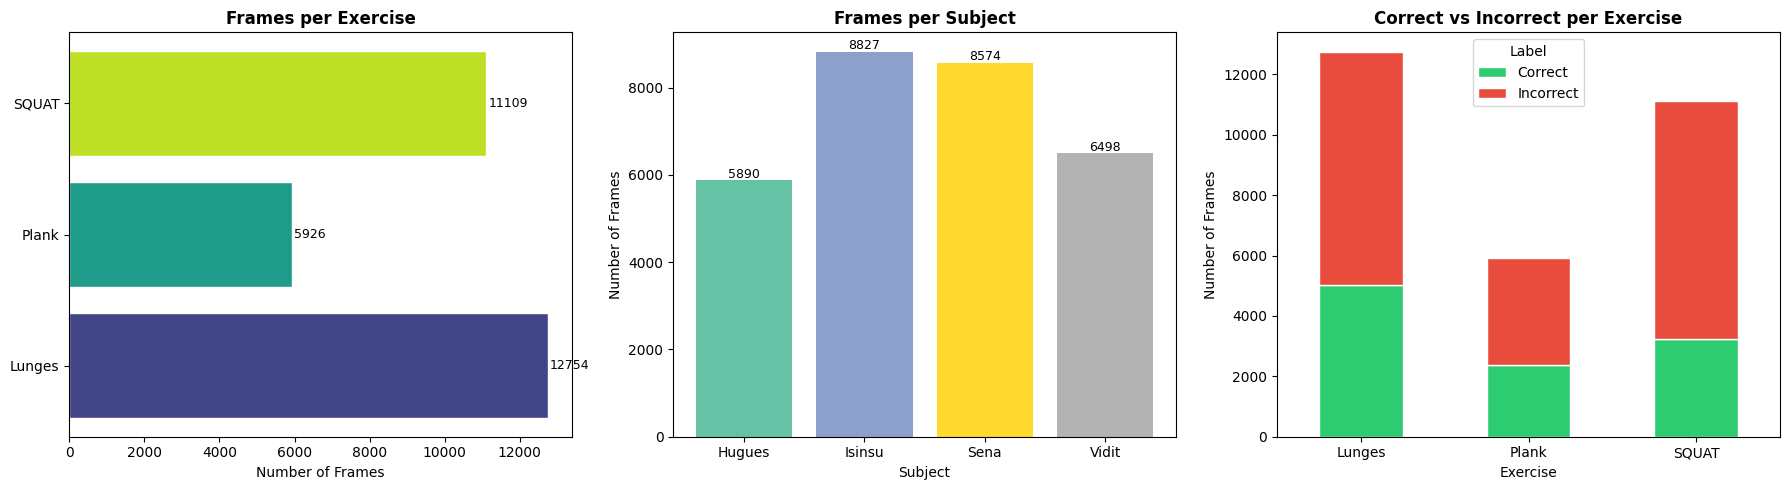

In [10]:
# Visualization: Exercise distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar chart: frames per exercise
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(exercise_counts)))
axes[0].barh(exercise_counts.index, exercise_counts.values, color=colors, edgecolor='white')
axes[0].set_xlabel('Number of Frames')
axes[0].set_title('Frames per Exercise', fontweight='bold')
for i, (ex, cnt) in enumerate(exercise_counts.items()):
    axes[0].text(cnt + 50, i, str(cnt), va='center', fontsize=9)

# Bar chart: frames per subject
sub_counts = labels_df['sub'].value_counts().sort_index()
axes[1].bar(sub_counts.index.astype(str), sub_counts.values, color=plt.cm.Set2(np.linspace(0, 1, len(sub_counts))))
axes[1].set_xlabel('Subject')
axes[1].set_ylabel('Number of Frames')
axes[1].set_title('Frames per Subject', fontweight='bold')
for i, (sub, cnt) in enumerate(sub_counts.items()):
    axes[1].text(i, cnt + 50, str(cnt), ha='center', fontsize=9)

# Stacked bar: correct vs incorrect per exercise
correct_incorrect = labels_df.groupby(['act', labels_df['lab'].apply(lambda x: 'Correct' if x == 1 else 'Incorrect')]).size().unstack(fill_value=0)
correct_incorrect.plot(kind='bar', stacked=True, ax=axes[2], color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[2].set_xlabel('Exercise')
axes[2].set_ylabel('Number of Frames')
axes[2].set_title('Correct vs Incorrect per Exercise', fontweight='bold')
axes[2].legend(title='Label')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [11]:
# Detailed label breakdown (mistake types per exercise)
print("\n" + "=" * 60)
print("  LABEL BREAKDOWN (Mistake Types)")
print("=" * 60)

label_breakdown = labels_df.groupby(['act', 'lab']).size().reset_index(name='frames')
for ex in sorted(labels_df['act'].unique()):
    print(f"\n  📌 {ex}:")
    subset = label_breakdown[label_breakdown['act'] == ex]
    for _, row in subset.iterrows():
        status = '✅ Correct' if row['lab'] == 1 else f'❌ Mistake {row["lab"]}'
        print(f"     Label {row['lab']:2d} ({status}): {row['frames']:5d} frames")


  LABEL BREAKDOWN (Mistake Types)

  📌 Lunges:
     Label  1 (✅ Correct):  5010 frames
     Label  4 (❌ Mistake 4):  3673 frames
     Label  6 (❌ Mistake 6):  4071 frames

  📌 Plank:
     Label  1 (✅ Correct):  2386 frames
     Label  7 (❌ Mistake 7):  1584 frames
     Label  8 (❌ Mistake 8):  1956 frames

  📌 SQUAT:
     Label  1 (✅ Correct):  3227 frames
     Label  2 (❌ Mistake 2):  1635 frames
     Label  3 (❌ Mistake 3):  1854 frames
     Label  4 (❌ Mistake 4):  1527 frames
     Label  5 (❌ Mistake 5):  2040 frames
     Label 10 (❌ Mistake 10):   826 frames


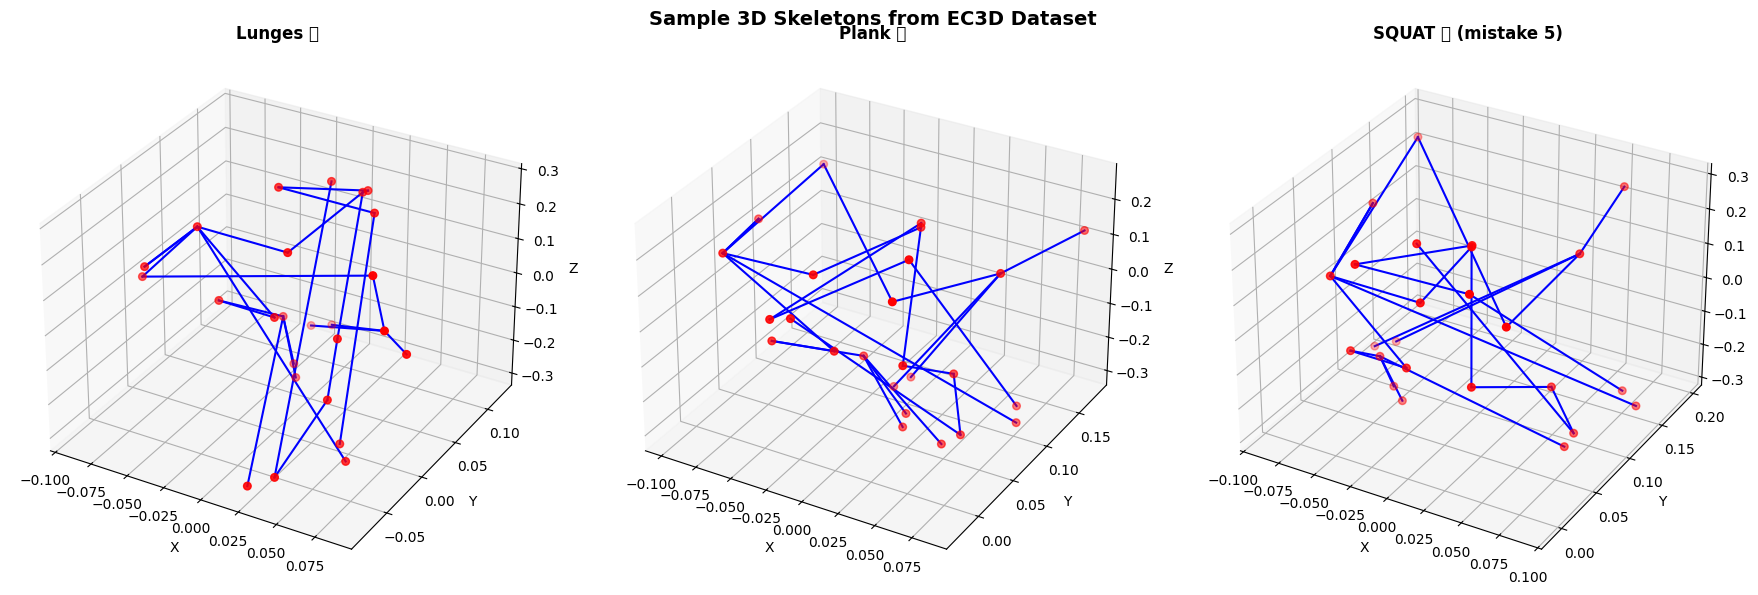

In [12]:
# Visualize a sample 3D skeleton
# EC3D 25-joint skeleton connections (based on Kinect/NTU skeleton)
EC3D_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3),        # spine: base → mid → neck → head
    (0, 12), (12, 13), (13, 14),    # right leg: base → hip → knee → ankle
    (0, 16), (16, 17), (17, 18),    # left leg: base → hip → knee → ankle
    (2, 4), (4, 5), (5, 6), (6, 7), # left arm: neck → shoulder → elbow → wrist → hand
    (2, 8), (8, 9), (9, 10), (10, 11), # right arm
    (3, 2),                          # head
    (14, 15), (18, 19),              # feet
    (6, 22), (6, 23), (10, 24), (10, 21), # finger tips
    (20, 2),                         # additional spine
]

# Plot 3 sample frames from different exercises
fig = plt.figure(figsize=(18, 6))
exercises = sorted(labels_df['act'].unique())

for idx, ex in enumerate(exercises[:3]):
    ex_mask = labels_df['act'] == ex
    sample_idx = labels_df[ex_mask].index[len(labels_df[ex_mask]) // 2]  # middle frame
    pose = poses[sample_idx]  # shape: (3, 25)

    ax = fig.add_subplot(1, 3, idx + 1, projection='3d')
    x, y, z = pose[0], pose[1], pose[2]

    ax.scatter(x, y, z, c='red', s=30, depthshade=True)
    for i, j in EC3D_CONNECTIONS:
        if i < 25 and j < 25:
            ax.plot([x[i], x[j]], [y[i], y[j]], [z[i], z[j]], 'b-', linewidth=1.5)

    lab_val = labels_df.iloc[sample_idx]['lab']
    status = '✅' if lab_val == 1 else f'❌ (mistake {lab_val})'
    ax.set_title(f"{ex} {status}", fontweight='bold')
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')

plt.suptitle('Sample 3D Skeletons from EC3D Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Build Sequences from Pre-Stored Landmarks

Group frames by `(act, sub, lab, rep)` to reconstruct action sequences.  
Unlike the pose notebook, **we skip MediaPipe** — landmarks are already in the pickle.

In [13]:
# Group frames into action sequences
labels_df['global_idx'] = labels_df.index  # track original index into poses array

sequences = []
for (act, sub, lab, rep), group in labels_df.groupby(['act', 'sub', 'lab', 'rep']):
    indices = group['global_idx'].values
    seq_poses = poses[indices]  # (T, 3, 25)
    sequences.append({
        'act': act,
        'sub': sub,
        'lab': lab,
        'rep': rep,
        'poses': seq_poses,
        'n_frames': len(indices),
    })

seq_df = pd.DataFrame([{k: v for k, v in s.items() if k != 'poses'} for s in sequences])
print(f"Total sequences: {len(sequences)}")
print(f"\nSequence length stats:")
print(seq_df['n_frames'].describe())
print(f"\nSequences per exercise:")
print(seq_df.groupby('act').size())
print(f"\nSequences per (exercise, label):")
print(seq_df.groupby(['act', 'lab']).size())

Total sequences: 371

Sequence length stats:
count    371.000000
mean      80.293801
std       27.973394
min       24.000000
25%       58.500000
50%       79.000000
75%       97.000000
max      208.000000
Name: n_frames, dtype: float64

Sequences per exercise:
act
Lunges    127
Plank     103
SQUAT     141
dtype: int64

Sequences per (exercise, label):
act     lab
Lunges  1      46
        4      40
        6      41
Plank   1      33
        7      30
        8      40
SQUAT   1      41
        2      23
        3      23
        4      21
        5      24
        10      9
dtype: int64


---
## 5. Feature Engineering (Using Pre-Stored 3D Landmarks)

For each sequence, compute:
- **Normalized landmarks** (hip-centred, torso-length scaled) → 25×3 = 75 features
- **Landmark velocity** (frame-to-frame Δ) → 25×3 = 75 features
- **Joint angles** (elbow, knee, hip – left & right) → 6 features
- **Angular velocity** → 6 features

Total: **162 features** per frame → output shape `(T, 162)`

> **Note**: EC3D uses 25 joints with 3D coordinates (x, y, z) vs the pose notebook's 33 MediaPipe joints with (x, y, z, visibility).

In [14]:
# EC3D 25-Joint Index Mapping
# Based on NTU RGB+D / Kinect skeleton
EC3D_IDX = {
    'BASE_SPINE':      0,
    'MID_SPINE':       1,
    'NECK':            2,
    'HEAD':            3,
    'LEFT_SHOULDER':   4,
    'LEFT_ELBOW':      5,
    'LEFT_WRIST':      6,
    'LEFT_HAND':       7,
    'RIGHT_SHOULDER':  8,
    'RIGHT_ELBOW':     9,
    'RIGHT_WRIST':    10,
    'RIGHT_HAND':     11,
    'LEFT_HIP':       12,
    'LEFT_KNEE':      13,
    'LEFT_ANKLE':     14,
    'LEFT_FOOT':      15,
    'RIGHT_HIP':      16,
    'RIGHT_KNEE':     17,
    'RIGHT_ANKLE':    18,
    'RIGHT_FOOT':     19,
    'SPINE':          20,
    'LEFT_HAND_TIP':  21,
    'LEFT_THUMB':     22,
    'RIGHT_HAND_TIP': 23,
    'RIGHT_THUMB':    24,
}

# Angle definitions: (name, [joint_a, joint_b (vertex), joint_c])
EC3D_ANGLE_DEFS = [
    ('LEFT_ELBOW',  [EC3D_IDX['LEFT_SHOULDER'],  EC3D_IDX['LEFT_ELBOW'],  EC3D_IDX['LEFT_WRIST']]),
    ('RIGHT_ELBOW', [EC3D_IDX['RIGHT_SHOULDER'], EC3D_IDX['RIGHT_ELBOW'], EC3D_IDX['RIGHT_WRIST']]),
    ('LEFT_KNEE',   [EC3D_IDX['LEFT_HIP'],       EC3D_IDX['LEFT_KNEE'],   EC3D_IDX['LEFT_ANKLE']]),
    ('RIGHT_KNEE',  [EC3D_IDX['RIGHT_HIP'],      EC3D_IDX['RIGHT_KNEE'],  EC3D_IDX['RIGHT_ANKLE']]),
    ('LEFT_HIP',    [EC3D_IDX['LEFT_SHOULDER'],   EC3D_IDX['LEFT_HIP'],    EC3D_IDX['LEFT_KNEE']]),
    ('RIGHT_HIP',   [EC3D_IDX['RIGHT_SHOULDER'],  EC3D_IDX['RIGHT_HIP'],   EC3D_IDX['RIGHT_KNEE']]),
]


def angle_3d(a, b, c):
    """Compute angle at vertex b given 3D points a, b, c."""
    ba = a - b
    bc = c - b
    cosine = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
    return np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0)))


def normalize_landmarks_3d(poses_seq):
    """
    Normalize a sequence of 3D poses.
    Input:  (T, 3, 25) — T frames, 3 coords, 25 joints
    Output: (T, 25, 3) — normalized, hip-centred, torso-scaled
    """
    # Transpose to (T, 25, 3) for easier manipulation
    lm = poses_seq.transpose(0, 2, 1).copy()  # (T, 25, 3)

    # Hip center = midpoint of left_hip and right_hip
    left_hip  = lm[:, EC3D_IDX['LEFT_HIP'], :]   # (T, 3)
    right_hip = lm[:, EC3D_IDX['RIGHT_HIP'], :]   # (T, 3)
    hip_center = (left_hip + right_hip) / 2.0      # (T, 3)

    # Center on hip
    lm -= hip_center[:, None, :]  # (T, 25, 3)

    # Scale by torso length (hip_center to shoulder_center)
    left_sh  = lm[:, EC3D_IDX['LEFT_SHOULDER'], :]
    right_sh = lm[:, EC3D_IDX['RIGHT_SHOULDER'], :]
    shoulder_center = (left_sh + right_sh) / 2.0
    torso_length = np.linalg.norm(shoulder_center, axis=1)  # hip is at origin
    torso_length[torso_length == 0] = 1e-6
    lm /= torso_length[:, None, None]

    return lm  # (T, 25, 3)


def extract_angles_3d(frame_xyz):
    """Extract joint angles from a single frame. frame_xyz: (25, 3)"""
    angles = []
    for name, (ja, jb, jc) in EC3D_ANGLE_DEFS:
        angles.append(angle_3d(frame_xyz[ja], frame_xyz[jb], frame_xyz[jc]))
    return np.array(angles)


def process_sequence_features(seq_poses):
    """
    Full feature engineering for one action sequence.
    Input:  (T, 3, 25)
    Output: (T, 162) feature vector per frame
    """
    T = seq_poses.shape[0]
    lm_norm = normalize_landmarks_3d(seq_poses)  # (T, 25, 3)

    # Landmark velocity (frame-to-frame delta)
    lm_vel = np.zeros_like(lm_norm)
    lm_vel[1:] = lm_norm[1:] - lm_norm[:-1]

    # Joint angles for each frame
    angles_all = np.array([extract_angles_3d(frame) for frame in lm_norm])

    # Angular velocity
    angle_vel = np.zeros_like(angles_all)
    angle_vel[1:] = angles_all[1:] - angles_all[:-1]

    # Flatten and concatenate
    lm_flat     = lm_norm.reshape(T, -1)    # (T, 75)
    lm_vel_flat = lm_vel.reshape(T, -1)     # (T, 75)
    # angles_all: (T, 6)
    # angle_vel:  (T, 6)

    features = np.concatenate([lm_flat, lm_vel_flat, angles_all, angle_vel], axis=1)
    return features  # (T, 162)


print("Feature engineering functions defined.")
print(f"  Normalized landmarks : 25 joints × 3 coords = 75")
print(f"  Landmark velocities  : 25 joints × 3 coords = 75")
print(f"  Joint angles         : 6")
print(f"  Angular velocities   : 6")
print(f"  Total features/frame : 162")

Feature engineering functions defined.
  Normalized landmarks : 25 joints × 3 coords = 75
  Landmark velocities  : 25 joints × 3 coords = 75
  Joint angles         : 6
  Angular velocities   : 6
  Total features/frame : 162


In [15]:
# Run feature engineering on all sequences
from tqdm.notebook import tqdm

all_features = []
all_labels = []
all_meta = []

for seq in tqdm(sequences, desc='Feature engineering'):
    try:
        feats = process_sequence_features(seq['poses'])
        all_features.append(feats)
        all_labels.append(seq['lab'])
        all_meta.append({
            'act': seq['act'],
            'sub': seq['sub'],
            'lab': seq['lab'],
            'rep': seq['rep'],
            'n_frames': seq['n_frames'],
            'feat_shape': feats.shape,
        })
    except Exception as e:
        print(f"  ❌ Error: {seq['act']}/sub{seq['sub']}/lab{seq['lab']}/rep{seq['rep']}: {e}")

meta_df = pd.DataFrame(all_meta)
print(f"\nProcessed {len(all_features)} sequences successfully.")
print(f"Feature shapes: min frames={meta_df['n_frames'].min()}, max={meta_df['n_frames'].max()}, mean={meta_df['n_frames'].mean():.1f}")

# Sample check
print(f"\nSample feature shape: {all_features[0].shape}")
print(f"Sample feature range: min={all_features[0].min():.4f}, max={all_features[0].max():.4f}")

Feature engineering:   0%|          | 0/371 [00:00<?, ?it/s]


Processed 371 sequences successfully.
Feature shapes: min frames=24, max=208, mean=80.3

Sample feature shape: (64, 162)
Sample feature range: min=-6.5700, max=169.0860


---
## 6. Heuristic Rule-Based Evaluation

We use the **same rule-based evaluation** as the `pose.ipynb` notebook:  
- Define reference angle ranges for each exercise (from `exercise_config.py`)  
- Compare each frame's computed angles against those ranges  
- Flag form errors with human-readable feedback messages  

**No model training needed** — the pre-stored EC3D 3D landmarks are evaluated directly with heuristic rules.

### EC3D → Exercise Config Mapping
- `SQUAT`  → `squat`
- `Lunges` → not directly in config, so we define custom lunge thresholds
- `Plank`  → `plank`

In [16]:
# ============================================================
# EC3D Joint Mapping for Heuristic Evaluation
# ============================================================
# EC3D uses the NTU RGB+D 25-joint skeleton.
# We map to the joints needed by exercise_config.py metrics.

EC3D_HEURISTIC_MAP = {
    'shoulder':  (4, 8),    # (Left, Right) shoulder
    'elbow':     (5, 9),    # (Left, Right) elbow
    'wrist':     (6, 10),   # (Left, Right) wrist
    'hip':       (12, 16),  # (Left, Right) hip
    'knee':      (13, 17),  # (Left, Right) knee
    'ankle':     (14, 18),  # (Left, Right) ankle
    'hand':      (7, 11),   # (Left, Right) hand
}

# Exercise config: metrics + reference thresholds
# Adapted from exercise_config.py for the 3 EC3D exercises
EC3D_EXERCISE_CONFIGS = {
    'SQUAT': {
        'metrics': {
            'KNEE_ANGLE': {
                'type': 'angle',
                'joints': ['hip', 'knee', 'ankle'],
                'tolerance': 10.0,
                'message_high': 'Legs too straight (Lockout?).',
                'message_low': 'Bend knees less.',
                'hard_max': 175.0,
            },
            'HIP_EXTENSION': {
                'type': 'angle',
                'joints': ['shoulder', 'hip', 'knee'],
                'tolerance': 10.0,
                'message_high': 'Hips extended too much.',
                'message_low': 'Hips flexed too much (sitting back?).',
            },
        },
        'thresholds': {
            'KNEE_ANGLE_min': 60.0, 'KNEE_ANGLE_max': 170.0,
            'HIP_EXTENSION_min': 60.0, 'HIP_EXTENSION_max': 170.0,
        },
    },
    'Lunges': {
        'metrics': {
            'KNEE_ANGLE': {
                'type': 'angle',
                'joints': ['hip', 'knee', 'ankle'],
                'tolerance': 10.0,
                'message_high': 'Front knee too straight.',
                'message_low': 'Front knee bent too deep.',
                'hard_max': 175.0,
            },
            'HIP_EXTENSION': {
                'type': 'angle',
                'joints': ['shoulder', 'hip', 'knee'],
                'tolerance': 10.0,
                'message_high': 'Torso leaning back too much.',
                'message_low': 'Torso leaning forward too much.',
            },
        },
        'thresholds': {
            'KNEE_ANGLE_min': 70.0, 'KNEE_ANGLE_max': 170.0,
            'HIP_EXTENSION_min': 70.0, 'HIP_EXTENSION_max': 170.0,
        },
    },
    'Plank': {
        'metrics': {
            'BODY_LINE': {
                'type': 'distance_from_line',
                'joints': ['hip', 'shoulder', 'ankle'],
                'tolerance': 0.08,
                'message_high': 'Body not straight (Sagging or Piking).',
            },
        },
        'thresholds': {
            'BODY_LINE_min': 0.0, 'BODY_LINE_max': 0.15,
        },
    },
}

print('Heuristic configs defined for:', list(EC3D_EXERCISE_CONFIGS.keys()))

Heuristic configs defined for: ['SQUAT', 'Lunges', 'Plank']


In [17]:
def get_joint_coords(frame_xyz, joint_name, side_idx):
    """
    Get 3D coordinates for a joint from a (25, 3) frame.
    side_idx: 0 = left, 1 = right
    """
    if joint_name in ['vertical', 'horizontal']:
        return joint_name
    indices = EC3D_HEURISTIC_MAP.get(joint_name)
    if indices is None:
        return None
    return frame_xyz[indices[side_idx]]


def compute_metric_value(frame_xyz, metric_config, side_idx):
    """
    Compute a single metric value for one side of the body.
    frame_xyz: (25, 3)
    """
    joints = metric_config.get('joints', [])
    metric_type = metric_config.get('type', 'angle')

    points = []
    for j in joints:
        p = get_joint_coords(frame_xyz, j, side_idx)
        if p is None:
            return None
        points.append(p)

    if metric_type == 'angle' and len(points) == 3:
        a, b, c = points
        if isinstance(a, str):
            a = np.array([b[0], b[1] - 0.5, b[2]]) if a == 'vertical' else np.array([b[0] + 0.5, b[1], b[2]])
        if isinstance(c, str):
            c = np.array([b[0], b[1] - 0.5, b[2]]) if c == 'vertical' else np.array([b[0] + 0.5, b[1], b[2]])
        ba = a - b
        bc = c - b
        n1, n2 = np.linalg.norm(ba), np.linalg.norm(bc)
        if n1 > 1e-6 and n2 > 1e-6:
            cos_a = np.dot(ba, bc) / (n1 * n2)
            return np.degrees(np.arccos(np.clip(cos_a, -1.0, 1.0)))

    elif metric_type == 'distance_from_line' and len(points) == 3:
        p0, p1, p2 = np.array(points[0]), np.array(points[1]), np.array(points[2])
        line_len = np.linalg.norm(p1 - p0)
        if line_len > 1e-6:
            return np.linalg.norm(np.cross(p1 - p0, p0 - p2)) / line_len

    return None


def evaluate_frame(frame_xyz, metric_configs, thresholds):
    """
    Evaluate a single frame using heuristic rules.
    Returns (is_good_form, feedback_messages, computed_metrics).
    """
    is_good_form = True
    feedback_messages = []
    computed_metrics = {}

    for metric_name, config in metric_configs.items():
        base_tol = config.get('tolerance', 10.0)
        msg_high = config.get('message_high', '')
        msg_low = config.get('message_low', '')

        ref_min = thresholds.get(f'{metric_name}_min')
        ref_max = thresholds.get(f'{metric_name}_max')
        if ref_min is None or ref_max is None:
            continue

        for side_idx, side_name in enumerate(['left', 'right']):
            val = compute_metric_value(frame_xyz, config, side_idx)
            if val is None:
                continue

            computed_metrics[f'{metric_name}_{side_name}'] = val

            lower_bound = ref_min - base_tol
            upper_bound = ref_max + base_tol

            hard_max = config.get('hard_max')
            if hard_max is not None:
                upper_bound = min(upper_bound, hard_max)
            hard_min = config.get('hard_min')
            if hard_min is not None:
                lower_bound = max(lower_bound, hard_min)

            if val < lower_bound:
                is_good_form = False
                if msg_low:
                    feedback_messages.append(f'[{side_name.upper()}] {msg_low}')
            elif val > upper_bound:
                is_good_form = False
                if msg_high:
                    feedback_messages.append(f'[{side_name.upper()}] {msg_high}')

    return is_good_form, feedback_messages, computed_metrics


print('Heuristic evaluation functions defined.')

Heuristic evaluation functions defined.


In [18]:
# ============================================================
# Run heuristic evaluation on all sequences
# ============================================================
from tqdm.notebook import tqdm

eval_results = []

for seq in tqdm(sequences, desc='Heuristic evaluation'):
    act = seq['act']
    config = EC3D_EXERCISE_CONFIGS.get(act)
    if config is None:
        continue

    metric_configs = config['metrics']
    thresholds = config['thresholds']
    poses_seq = seq['poses']  # (T, 3, 25)

    # Normalize the sequence (hip-centred, torso-scaled)
    lm_norm = normalize_landmarks_3d(poses_seq)  # (T, 25, 3)

    good_frames = 0
    total_frames = lm_norm.shape[0]
    all_feedback = []
    all_metric_vals = {}

    for t in range(total_frames):
        frame = lm_norm[t]  # (25, 3)
        is_good, msgs, metrics = evaluate_frame(frame, metric_configs, thresholds)
        if is_good:
            good_frames += 1
        all_feedback.extend(msgs)
        for k, v in metrics.items():
            all_metric_vals.setdefault(k, []).append(v)

    good_form_pct = good_frames / total_frames * 100 if total_frames > 0 else 0

    eval_results.append({
        'act': act,
        'sub': seq['sub'],
        'lab': seq['lab'],
        'rep': seq['rep'],
        'n_frames': total_frames,
        'good_frames': good_frames,
        'good_form_pct': good_form_pct,
        'is_correct': seq['lab'] == 1,
        'top_feedback': Counter(all_feedback).most_common(3),
        'metric_vals': {k: {'min': np.min(v), 'max': np.max(v), 'mean': np.mean(v)} for k, v in all_metric_vals.items()},
    })

eval_df = pd.DataFrame(eval_results)
print(f'\nEvaluated {len(eval_df)} sequences.')
print(f'Exercises: {eval_df["act"].unique().tolist()}')

Heuristic evaluation:   0%|          | 0/371 [00:00<?, ?it/s]


Evaluated 371 sequences.
Exercises: ['Lunges', 'Plank', 'SQUAT']


---
## 7. Evaluation Results

Analyse how well the heuristic rules distinguish **correct** (lab=1) from **incorrect** sequences.

In [19]:
# ============================================================
# Good-form percentage: correct vs incorrect sequences
# ============================================================
print('=' * 60)
print('  HEURISTIC EVALUATION RESULTS')
print('=' * 60)

for ex in sorted(eval_df['act'].unique()):
    print(f'\n  📌 {ex}:')
    ex_data = eval_df[eval_df['act'] == ex]

    correct = ex_data[ex_data['is_correct']]
    incorrect = ex_data[~ex_data['is_correct']]

    if len(correct) > 0:
        print(f'     ✅ Correct   ({len(correct):3d} seqs): '
              f'avg good-form = {correct["good_form_pct"].mean():.1f}%, '
              f'median = {correct["good_form_pct"].median():.1f}%')
    if len(incorrect) > 0:
        print(f'     ❌ Incorrect ({len(incorrect):3d} seqs): '
              f'avg good-form = {incorrect["good_form_pct"].mean():.1f}%, '
              f'median = {incorrect["good_form_pct"].median():.1f}%')

    if len(correct) > 0 and len(incorrect) > 0:
        diff = correct['good_form_pct'].mean() - incorrect['good_form_pct'].mean()
        print(f'     📊 Δ (correct − incorrect) = {diff:+.1f} pp')

  HEURISTIC EVALUATION RESULTS

  📌 Lunges:
     ✅ Correct   ( 46 seqs): avg good-form = 0.1%, median = 0.0%
     ❌ Incorrect ( 81 seqs): avg good-form = 0.0%, median = 0.0%
     📊 Δ (correct − incorrect) = +0.1 pp

  📌 Plank:
     ✅ Correct   ( 33 seqs): avg good-form = 0.0%, median = 0.0%
     ❌ Incorrect ( 70 seqs): avg good-form = 0.0%, median = 0.0%
     📊 Δ (correct − incorrect) = +0.0 pp

  📌 SQUAT:
     ✅ Correct   ( 41 seqs): avg good-form = 1.3%, median = 0.0%
     ❌ Incorrect (100 seqs): avg good-form = 4.0%, median = 0.0%
     📊 Δ (correct − incorrect) = -2.7 pp


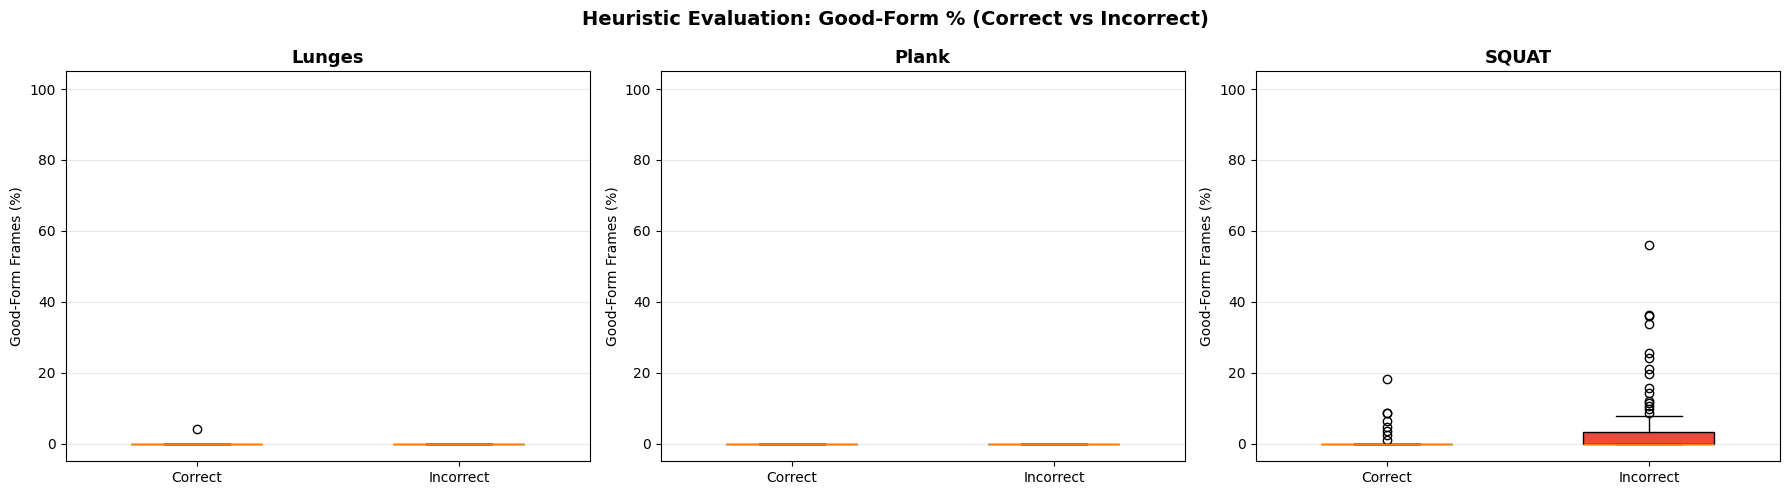

In [20]:
# Box plot: good-form % by exercise and correctness
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
exercises = sorted(eval_df['act'].unique())

for i, ex in enumerate(exercises):
    ax = axes[i]
    ex_data = eval_df[eval_df['act'] == ex]

    correct_vals = ex_data[ex_data['is_correct']]['good_form_pct'].values
    incorrect_vals = ex_data[~ex_data['is_correct']]['good_form_pct'].values

    data_to_plot = [correct_vals, incorrect_vals]
    bp = ax.boxplot(data_to_plot, labels=['Correct', 'Incorrect'],
                    patch_artist=True, widths=0.5)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')

    ax.set_title(f'{ex}', fontweight='bold', fontsize=13)
    ax.set_ylabel('Good-Form Frames (%)')
    ax.set_ylim(-5, 105)
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('Heuristic Evaluation: Good-Form % (Correct vs Incorrect)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


  BINARY CLASSIFICATION (Threshold Sweep)

  Best threshold: 60%
  Best accuracy:  0.6765 (67.7%)

              precision    recall  f1-score   support

   Incorrect       0.68      1.00      0.81       251
     Correct       0.00      0.00      0.00       120

    accuracy                           0.68       371
   macro avg       0.34      0.50      0.40       371
weighted avg       0.46      0.68      0.55       371



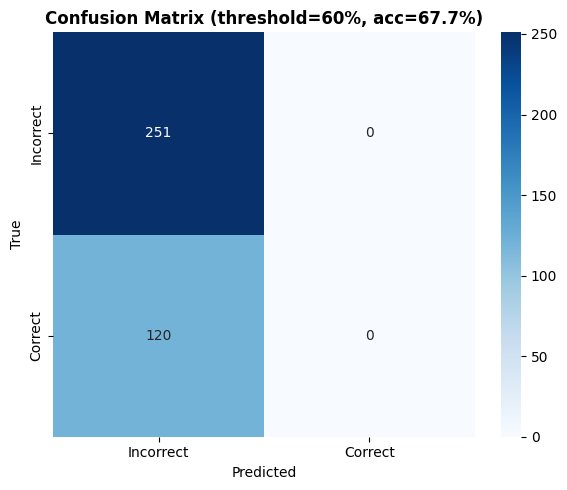

In [21]:
# ============================================================
# Binary classification: can we distinguish correct vs incorrect
# using a simple threshold on good-form %?
# ============================================================
print('\n' + '=' * 60)
print('  BINARY CLASSIFICATION (Threshold Sweep)')
print('=' * 60)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_true = eval_df['is_correct'].astype(int).values
scores = eval_df['good_form_pct'].values

best_acc = 0.0
best_thresh = 50.0

for thresh in np.arange(10, 100, 5):
    y_pred = (scores >= thresh).astype(int)
    acc = accuracy_score(y_true, y_pred)
    if acc > best_acc:
        best_acc = acc
        best_thresh = thresh

print(f'\n  Best threshold: {best_thresh:.0f}%')
print(f'  Best accuracy:  {best_acc:.4f} ({best_acc*100:.1f}%)')

# Final predictions at best threshold
y_pred_best = (scores >= best_thresh).astype(int)

print(f'\n{classification_report(y_true, y_pred_best, target_names=["Incorrect", "Correct"], zero_division=0)}')

cm = confusion_matrix(y_true, y_pred_best)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Incorrect', 'Correct'],
            yticklabels=['Incorrect', 'Correct'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix (threshold={best_thresh:.0f}%, acc={best_acc:.1%})',
             fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# Per-exercise accuracy at the best global threshold
# ============================================================
print('\n' + '=' * 60)
print('  PER-EXERCISE ACCURACY')
print('=' * 60)

for ex in sorted(eval_df['act'].unique()):
    mask = eval_df['act'] == ex
    ex_true = y_true[mask]
    ex_pred = y_pred_best[mask]
    ex_acc = accuracy_score(ex_true, ex_pred)
    print(f'  {ex:>10s}: {ex_acc:.4f} ({ex_acc*100:.1f}%) — {mask.sum()} sequences')


  PER-EXERCISE ACCURACY
      Lunges: 0.6378 (63.8%) — 127 sequences
       Plank: 0.6796 (68.0%) — 103 sequences
       SQUAT: 0.7092 (70.9%) — 141 sequences


In [23]:
# ============================================================
# Most common feedback messages for INCORRECT sequences
# ============================================================
print('\n' + '=' * 60)
print('  TOP FEEDBACK MESSAGES (Incorrect sequences only)')
print('=' * 60)

for ex in sorted(eval_df['act'].unique()):
    print(f'\n  📌 {ex}:')
    incorrect = eval_df[(eval_df['act'] == ex) & (~eval_df['is_correct'])]
    all_fb = Counter()
    for _, row in incorrect.iterrows():
        for msg, count in row['top_feedback']:
            all_fb[msg] += count
    for msg, count in all_fb.most_common(5):
        print(f'     {count:5d}× {msg}')


  TOP FEEDBACK MESSAGES (Incorrect sequences only)

  📌 Lunges:
      7744× [RIGHT] Front knee bent too deep.
       313× [LEFT] Front knee too straight.
        72× [RIGHT] Torso leaning forward too much.

  📌 Plank:
      3540× [LEFT] Body not straight (Sagging or Piking).
      3240× [RIGHT] Body not straight (Sagging or Piking).

  📌 SQUAT:
      7548× [RIGHT] Bend knees less.
       389× [LEFT] Hips flexed too much (sitting back?).
       246× [LEFT] Legs too straight (Lockout?).
       115× [LEFT] Bend knees less.
       112× [RIGHT] Hips flexed too much (sitting back?).


---
## 8. Final Summary

In [24]:
print('\n' + '=' * 60)
print('  📋 FINAL SUMMARY')
print('=' * 60)

print(f'\n  Dataset: EC3D (Exercise Correction in 3D)')
print(f'  Pickle file: {os.path.basename(PICKLE_PATH)}')
print(f'  Total frames: {len(labels_df):,}')
print(f'  Total sequences: {len(sequences)}')
print(f'  Exercises: {sorted(eval_df["act"].unique().tolist())}')
print(f'  Joints: 25 (pre-stored 3D landmarks — no MediaPipe needed)')

print(f'\n  🔧 Evaluation Method: Heuristic rule-based')
print(f'     - Same approach as pose.ipynb (exercise_config.py)')
print(f'     - Joint angles compared against reference ranges')
print(f'     - ±tolerance thresholds with human-readable feedback')

print(f'\n  🏆 Results:')
print(f'    Binary accuracy (correct vs incorrect): {best_acc:.4f} ({best_acc*100:.1f}%)')
print(f'    Threshold: {best_thresh:.0f}% good-form frames')

print(f'\n  ✅ Pipeline complete!')
print(f'     Pre-stored EC3D landmarks → Normalize → Heuristic rules → Evaluation')


  📋 FINAL SUMMARY

  Dataset: EC3D (Exercise Correction in 3D)
  Pickle file: data_3D.pickle
  Total frames: 29,789
  Total sequences: 371
  Exercises: ['Lunges', 'Plank', 'SQUAT']
  Joints: 25 (pre-stored 3D landmarks — no MediaPipe needed)

  🔧 Evaluation Method: Heuristic rule-based
     - Same approach as pose.ipynb (exercise_config.py)
     - Joint angles compared against reference ranges
     - ±tolerance thresholds with human-readable feedback

  🏆 Results:
    Binary accuracy (correct vs incorrect): 0.6765 (67.7%)
    Threshold: 60% good-form frames

  ✅ Pipeline complete!
     Pre-stored EC3D landmarks → Normalize → Heuristic rules → Evaluation


In [25]:
# (Optional) Save evaluation results to Drive
SAVE_TO_DRIVE = False

if SAVE_TO_DRIVE:
    drive_output = os.path.join(DRIVE_ROOT, 'EC3D_results')
    os.makedirs(drive_output, exist_ok=True)
    # Save eval_df (drop non-serializable columns)
    save_df = eval_df.drop(columns=['top_feedback', 'metric_vals'])
    save_df.to_csv(os.path.join(drive_output, 'ec3d_eval_results.csv'), index=False)
    print(f'✅ Results saved to {drive_output}')
else:
    print('Skipping Drive save.')
    print('⚠️ Results will be lost when the runtime disconnects!')

Skipping Drive save.
⚠️ Results will be lost when the runtime disconnects!
